In [5]:
import pandas as pd

df = pd.read_csv("/content/spam_ham_dataset.csv")
df.head()

,Unnamed: 0,label,text,label_num
0,605,ham,Subject: enron methanol ; meter # : 988291\r\n...,0
1,2349,ham,"Subject: hpl nom for january 9 , 2001\r\n( see...",0
2,3624,ham,"Subject: neon retreat\r\nho ho ho , we ' re ar...",0
3,4685,spam,"Subject: photoshop , windows , office . cheap ...",1
4,2030,ham,Subject: re : indian springs\r\nthis deal is t...,0


In [6]:
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = text.lower()
    text = re.sub(r'\bsubject\b', '', text)
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words and len(w) > 2]
    return ' '.join(tokens)

df['clean_text'] = df['text'].apply(clean_text)
df[['text', 'clean_text']].head()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


,text,clean_text
0,Subject: enron methanol ; meter # : 988291\r\n...,enron methanol meter follow note gave monday p...
1,"Subject: hpl nom for january 9 , 2001\r\n( see...",hpl nom january see attached file hplnol xl hp...
2,"Subject: neon retreat\r\nho ho ho , we ' re ar...",neon retreat around wonderful time year neon l...
3,"Subject: photoshop , windows , office . cheap ...",photoshop window office cheap main trending ab...
4,Subject: re : indian springs\r\nthis deal is t...,indian spring deal book teco pvr revenue under...


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB

X_train, X_test, y_train, y_test = train_test_split(
    df['clean_text'], df['label_num'], test_size=0.2, random_state=42, stratify=df['label_num']
)

tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# Model 1: Logistic Regression
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_tfidf, y_train)

# Model 2: Naive Bayes
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

MultinomialNB()


Logistic Regression Accuracy: 0.9836
              precision    recall  f1-score   support

         ham       0.99      0.98      0.99       735
        spam       0.96      0.98      0.97       300

    accuracy                           0.98      1035
   macro avg       0.98      0.98      0.98      1035
weighted avg       0.98      0.98      0.98      1035



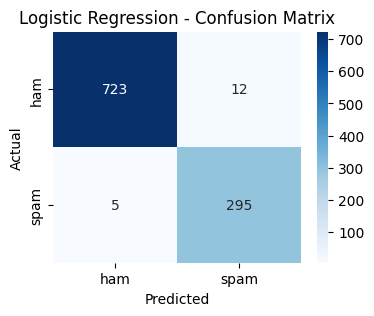


Naive Bayes Accuracy: 0.9517
              precision    recall  f1-score   support

         ham       0.97      0.96      0.97       735
        spam       0.91      0.93      0.92       300

    accuracy                           0.95      1035
   macro avg       0.94      0.94      0.94      1035
weighted avg       0.95      0.95      0.95      1035



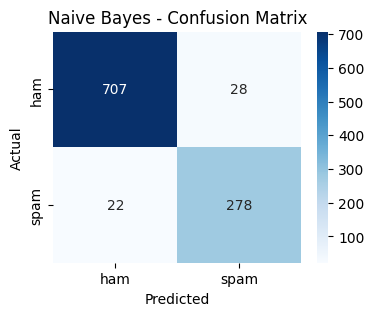

In [8]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

for name, model in [('Logistic Regression', lr_model), ('Naive Bayes', nb_model)]:
    preds = model.predict(X_test_tfidf)
    acc = accuracy_score(y_test, preds)
    print(f"\n{name} Accuracy: {acc:.4f}")
    print(classification_report(y_test, preds, target_names=['ham', 'spam']))

    cm = confusion_matrix(y_test, preds)
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['ham','spam'], yticklabels=['ham','spam'])
    plt.title(f'{name} - Confusion Matrix')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

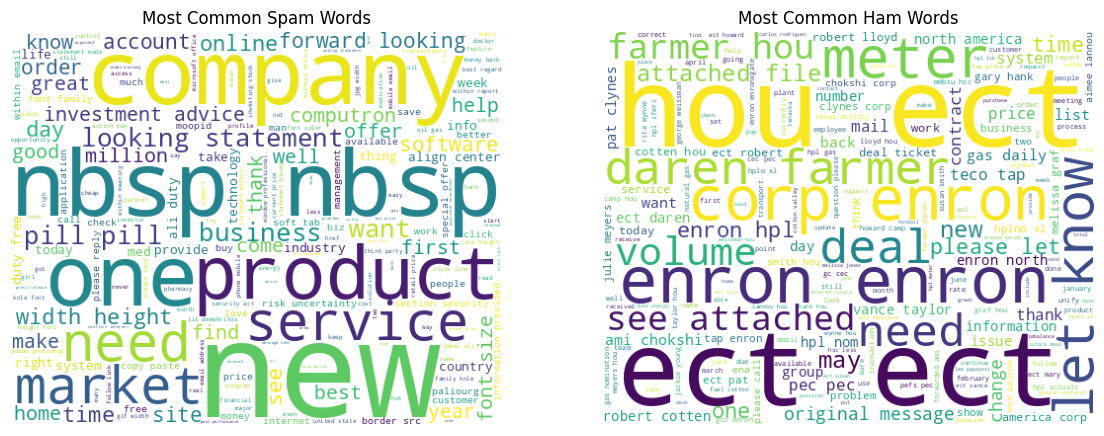

Total emails: 5171
Spam emails: 1499
Ham emails: 3672
Spam ratio: 28.99%


In [9]:
from wordcloud import WordCloud

spam_words = ' '.join(df[df['label_num'] == 1]['clean_text'])
ham_words = ' '.join(df[df['label_num'] == 0]['clean_text'])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
WordCloud(width=500, height=400, background_color='white').generate(spam_words)
axes[0].imshow(WordCloud(width=500, height=400, background_color='white').generate(spam_words))
axes[0].set_title('Most Common Spam Words')
axes[0].axis('off')

axes[1].imshow(WordCloud(width=500, height=400, background_color='white').generate(ham_words))
axes[1].set_title('Most Common Ham Words')
axes[1].axis('off')
plt.show()

# Summary stats
print("Total emails:", len(df))
print("Spam emails:", (df['label_num']==1).sum())
print("Ham emails:", (df['label_num']==0).sum())
print("Spam ratio: {:.2f}%".format((df['label_num']==1).mean()*100))